In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df.head(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."


In [3]:
#Get only US dataset and job title Data Analyst
df_DA_US = df[(df["job_country"] == "United States") & (df["job_title_short"] == "Data Analyst")].copy()
df_DA_US = df_DA_US.dropna(subset = ["salary_year_avg"])

In [6]:
df_DA_US_exploded = df_DA_US.explode("job_skills")

#Groupby follow by what we want to group, follow by values we want to count in [], 
#follow by the count method or agg for more than one, if use agg use a list to contain the count methods
#follow by any other method needed such as sort_values
df_DA_US_group = df_DA_US_exploded.groupby("job_skills")["salary_year_avg"].agg(['count', 'median'])
df_DA_toppay = df_DA_US_group.sort_values(by = 'median', ascending = False).head(10)
df_DA_skills = df_DA_US_group.sort_values(by = 'count', ascending = False).head(10)

<Axes: ylabel='job_skills'>

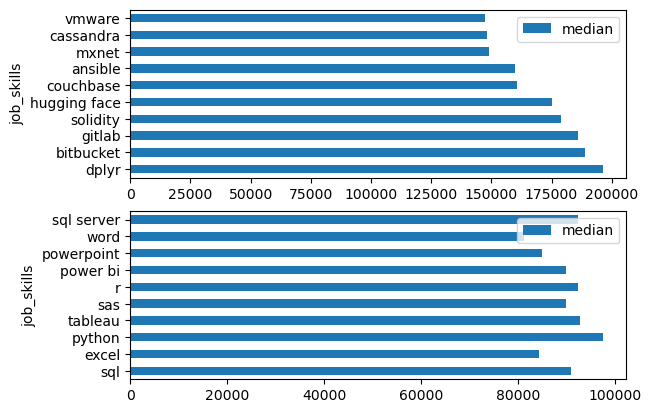

In [10]:
fig, ax  = plt.subplots(2, 1)
df_DA_toppay.plot(kind='barh', y='median', ax=ax[0])
df_DA_skills.plot(kind='barh', y='median', ax=ax[1])

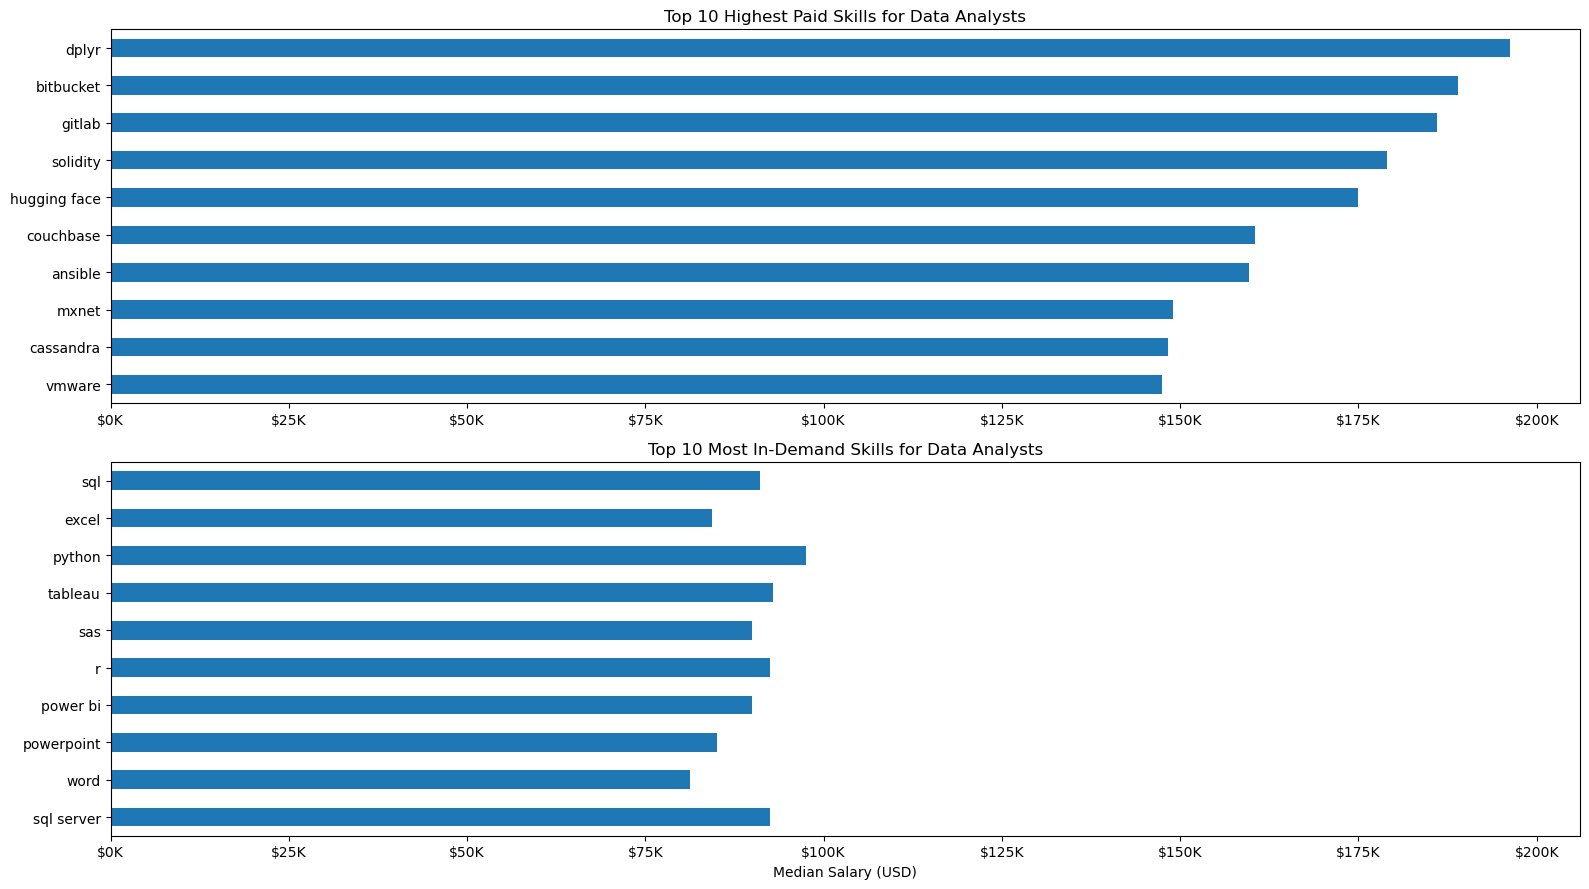

In [17]:
#Customizing the visualization


fig, ax = plt.subplots(2, 1)  

# Top 10 Highest Paid Skills for Data Analysts

#instead of using [::-1] to reverse the graph, we can use ax[0].invert_yaxis()
#set legend to false to hide it
df_DA_toppay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False, figsize=(16,9)) 
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Top 10 Most In-Demand Skills for Data Analysts
df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False, figsize=(16,9))
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()
